# Getting started with Lightkurve

In [1]:
%matplotlib inline
from lightkurve import search_targetpixelfile

/Users/shanekomeiji/miniforge3/envs/AstronomicalData/lib/python3.14/site-packages/lightkurve/prf/__init__.py:7: UserWarning: Warning: the tpfmodel submodule is not available without oktopus installed, which requires a current version of autograd. See #1452 for details.
  warnings.warn(


In [2]:
# First we open a Target Pixel File from MAST, this one is already cached from our previous tutorial!
tpf = search_targetpixelfile('KIC 6922244', author="Kepler", cadence="long", quarter=4).download()

# Then we convert the target pixel file into a light curve using the pipeline-defined aperture mask.
lc = tpf.to_lightcurve(aperture_mask=tpf.pipeline_mask)

In [3]:
lc.meta['MISSION']

'Kepler'

In [4]:
lc.meta['QUARTER']

4

In [5]:
lc.time

<Time object: scale='tdb' format='bkjd' value=[352.37632485 352.39675805 352.43762445 ... 442.16263546 442.18306983
 442.2035041 ]>

In [6]:
lc.flux

<Quantity [43689.15 , 43698.08 , 43694.105, ..., 43155.8  , 43148.465,
           43151.562] electron / s>

In [7]:
lc.estimate_cdpp()

<Quantity 75.29206549 ppm>

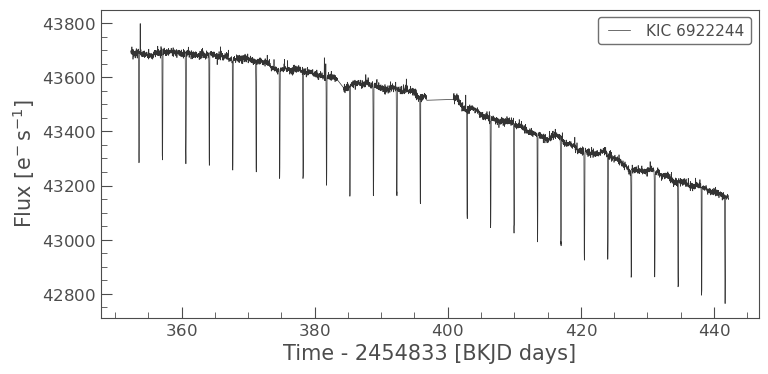

In [8]:
lc.plot();

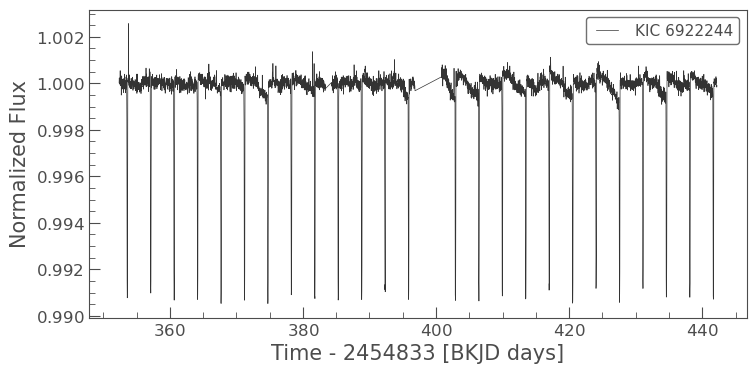

In [9]:
flat_lc = lc.flatten(window_length=401)
flat_lc.plot();

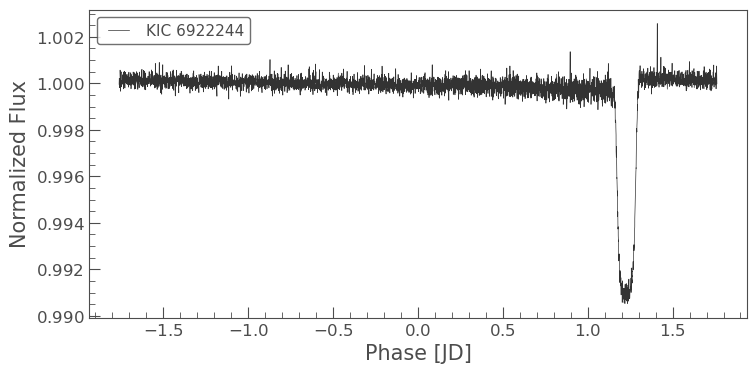

In [10]:
folded_lc = flat_lc.fold(period=3.5225)
folded_lc.plot();

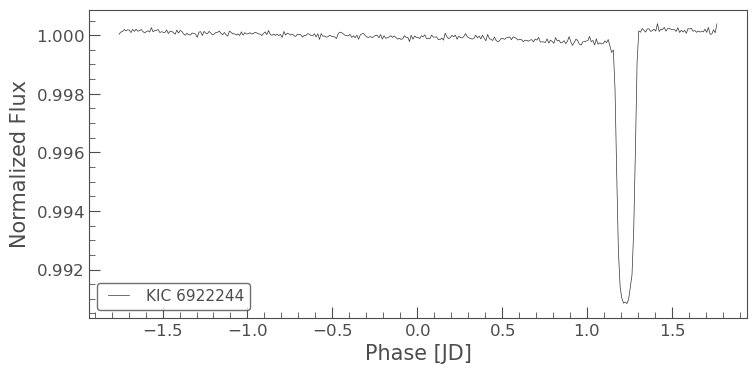

In [11]:
binned_lc = folded_lc.bin(time_bin_size=0.01)
binned_lc.plot();

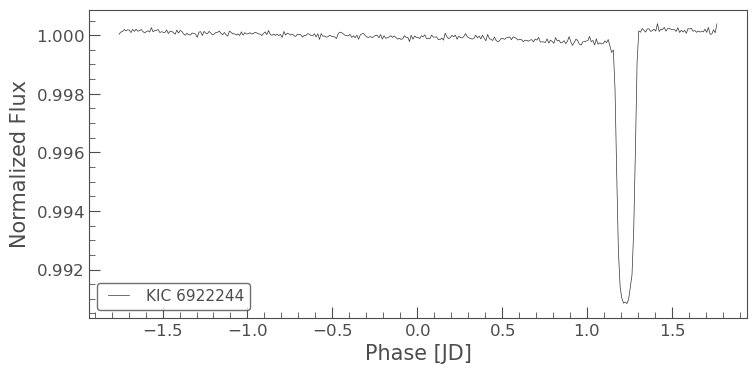

In [12]:
lc.remove_nans().flatten(window_length=401).fold(period=3.5225).bin(time_bin_size=0.01).plot();


# Downloading targets

In [14]:
%matplotlib inline
import lightkurve as lk
import matplotlib.pyplot as plt

In [15]:
search_result = lk.search_lightcurve('KIC 3733346', author='Kepler')
search_result

#,mission,year,author,exptime,target_name,distance
,,,,s,,arcsec
0,Kepler Quarter 01,2009,Kepler,1800,kplr003733346,0.0
1,Kepler Quarter 02,2009,Kepler,1800,kplr003733346,0.0
2,Kepler Quarter 03,2009,Kepler,1800,kplr003733346,0.0
3,Kepler Quarter 04,2010,Kepler,1800,kplr003733346,0.0
4,Kepler Quarter 05,2010,Kepler,1800,kplr003733346,0.0
5,Kepler Quarter 06,2010,Kepler,1800,kplr003733346,0.0
6,Kepler Quarter 07,2010,Kepler,1800,kplr003733346,0.0
7,Kepler Quarter 11,2011,Kepler,60,kplr003733346,0.0
8,Kepler Quarter 08,2011,Kepler,1800,kplr003733346,0.0


In [16]:
search_result[0]

#,mission,year,author,exptime,target_name,distance
,,,,s,,arcsec
0,Kepler Quarter 01,2009,Kepler,1800,kplr003733346,0.0


In [17]:
for column in search_result.table.columns:
  print(column)

intentType
obs_collection
provenance_name
instrument_name
project
filters
wave_region
target_name
target_classification
obs_id
s_ra
s_dec
dataproduct_type
proposal_pi
calib_level
t_min
t_max
t_exptime
wavelength_region
em_min
em_max
obs_title
t_obs_release
proposal_id
proposal_type
sequence_number
s_region
jpegURL
dataURL
dataRights
mtFlag
srcDen
obsid
objID
wave_min
wave_max
exptime
distance
obsID
obs_collection_products
dataproduct_type_products
description
type
dataURI
productType
productGroupDescription
productSubGroupDescription
productDocumentationURL
project_products
prvversion
proposal_id_products
productFilename
size
parent_obsid
dataRights_products
calib_level_products
filters_products
author
mission
#
year
sort_order


In [18]:
# import numpy, which we will use to find the desired index in the table
import numpy as np
quarter2_index = np.where(search_result.table['mission'] == 'Kepler Quarter 02')[0]
search_result[quarter2_index]

#,mission,year,author,exptime,target_name,distance
,,,,s,,arcsec
0,Kepler Quarter 02,2009,Kepler,1800,kplr003733346,0.0


In [19]:
search_result_q2 = lk.search_lightcurve('KIC 3733346', author='Kepler', quarter=2)
search_result_q2

#,mission,year,author,exptime,target_name,distance
,,,,s,,arcsec
0,Kepler Quarter 02,2009,Kepler,1800,kplr003733346,0.0


In [20]:
lc = search_result_q2.download()
lc

time,flux,flux_err,quality,timecorr,centroid_col,centroid_row,cadenceno,sap_flux,sap_flux_err,sap_bkg,sap_bkg_err,pdcsap_flux,pdcsap_flux_err,sap_quality,psf_centr1,psf_centr1_err,psf_centr2,psf_centr2_err,mom_centr1,mom_centr1_err,mom_centr2,mom_centr2_err,pos_corr1,pos_corr2
,electron / s,electron / s,,d,pix,pix,,electron / s,electron / s,electron / s,electron / s,electron / s,electron / s,,pix,pix,pix,pix,pix,pix,pix,pix,pix,pix
Time,float32,float32,int32,float32,float64,float64,int32,float32,float32,float32,float32,float32,float32,int32,float64,float32,float64,float32,float64,float32,float64,float32,float32,float32
169.7659418421681,9.2319516e+04,9.2697735e+00,0,3.263322e-03,781.81123,786.73051,2977,8.9092305e+04,8.8779488e+00,2.0773477e+03,7.0835429e-01,9.2319516e+04,9.2697735e+00,0,———,———,———,———,781.81123,1.2057812e-04,786.73051,1.4581889e-04,1.0092091e-01,-1.9298431e-01
169.7863760557957,8.9214008e+04,9.1563263e+00,0,3.263836e-03,781.80745,786.73005,2978,8.6126133e+04,8.7672691e+00,2.0793108e+03,7.0831001e-01,8.9214008e+04,9.1563263e+00,0,———,———,———,———,781.80745,1.2411721e-04,786.73005,1.5003627e-04,1.0036582e-01,-1.9279599e-01
169.80681006918894,8.5608195e+04,9.0206089e+00,0,3.264349e-03,781.80376,786.72918,2979,8.2681344e+04,8.6362791e+00,2.0772085e+03,7.0797533e-01,8.5608195e+04,9.0206089e+00,0,———,———,———,———,781.80376,1.2850568e-04,786.72918,1.5526263e-04,1.0042009e-01,-1.9289577e-01
169.8272442823436,8.3063625e+04,8.9255180e+00,0,3.264862e-03,781.80081,786.72913,2980,8.0246992e+04,8.5434341e+00,2.0767546e+03,7.0811391e-01,8.3063625e+04,8.9255180e+00,0,———,———,———,———,781.80081,1.3182692e-04,786.72913,1.5920549e-04,1.0021163e-01,-1.9266903e-01
169.84767829527118,8.4244992e+04,8.9700022e+00,0,3.265375e-03,781.80242,786.72905,2981,8.1373969e+04,8.5879698e+00,2.0805510e+03,7.0775980e-01,8.4244992e+04,8.9700022e+00,0,———,———,———,———,781.80242,1.3028238e-04,786.72905,1.5737538e-04,1.0010726e-01,-1.9241102e-01
169.86811250773462,9.7360805e+04,9.4567146e+00,0,3.265888e-03,781.81441,786.73210,2982,9.3887734e+04,9.0560179e+00,2.0782170e+03,7.0836788e-01,9.7360805e+04,9.4567146e+00,0,———,———,———,———,781.81441,1.1529749e-04,786.73210,1.3958653e-04,9.8970458e-02,-1.9224431e-01
169.88854651995644,1.2825345e+05,1.0503614e+01,0,3.266400e-03,781.83651,786.73500,2983,1.2337022e+05,1.0063412e+01,2.0774846e+03,7.0743954e-01,1.2825345e+05,1.0503614e+01,0,———,———,———,———,781.83651,9.1639682e-05,786.73500,1.1152634e-04,9.9608414e-02,-1.9224758e-01
169.90898063195345,1.5187158e+05,1.1233888e+01,0,3.266912e-03,781.84701,786.73606,2984,1.4590969e+05,1.0766508e+01,2.0792261e+03,7.0833290e-01,1.5187158e+05,1.1233888e+01,0,———,———,———,———,781.84701,7.9801415e-05,786.73606,9.7487238e-05,9.8825477e-02,-1.9200189e-01


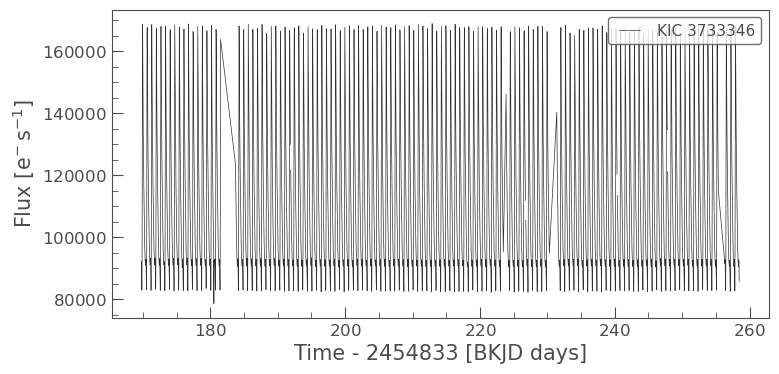

In [21]:
lc.plot();

In [22]:
lc_collection = search_result[:5].download_all()
lc_collection

LightCurveCollection of 5 objects:
    0: <KeplerLightCurve LABEL="KIC 3733346" QUARTER=1 AUTHOR=Kepler FLUX_ORIGIN=pdcsap_flux>
    1: <KeplerLightCurve LABEL="KIC 3733346" QUARTER=2 AUTHOR=Kepler FLUX_ORIGIN=pdcsap_flux>
    2: <KeplerLightCurve LABEL="KIC 3733346" QUARTER=3 AUTHOR=Kepler FLUX_ORIGIN=pdcsap_flux>
    3: <KeplerLightCurve LABEL="KIC 3733346" QUARTER=4 AUTHOR=Kepler FLUX_ORIGIN=pdcsap_flux>
    4: <KeplerLightCurve LABEL="KIC 3733346" QUARTER=5 AUTHOR=Kepler FLUX_ORIGIN=pdcsap_flux>

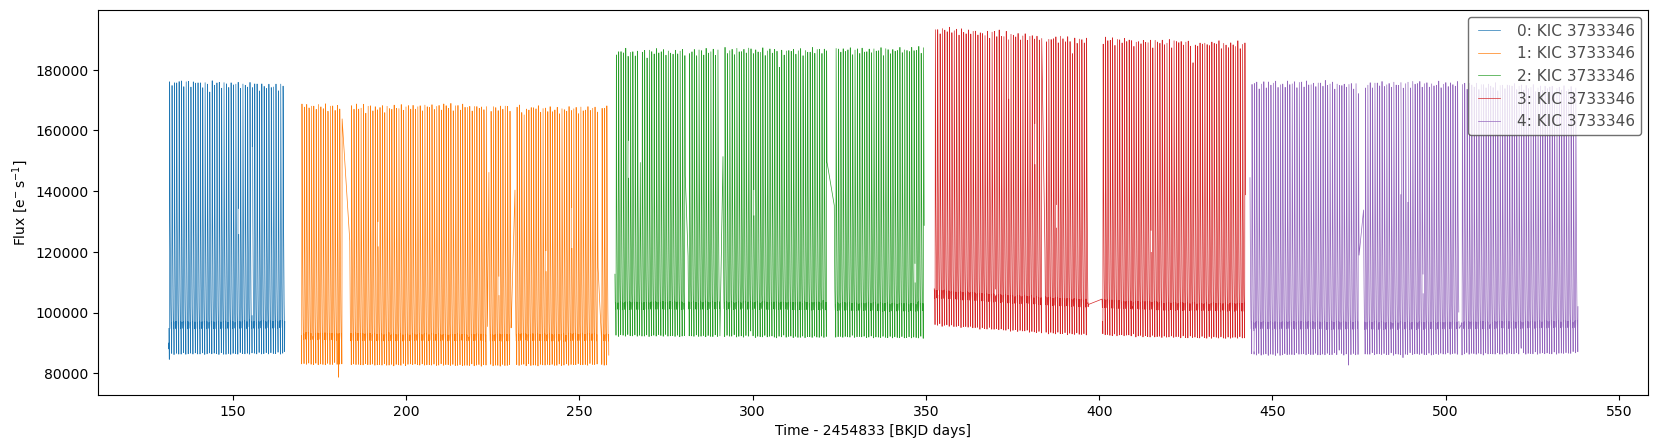

In [23]:
# Create a larger figure for clarity
fig, ax = plt.subplots(figsize=(20,5))
# Plot the light curve collection
lc_collection.plot(ax=ax);

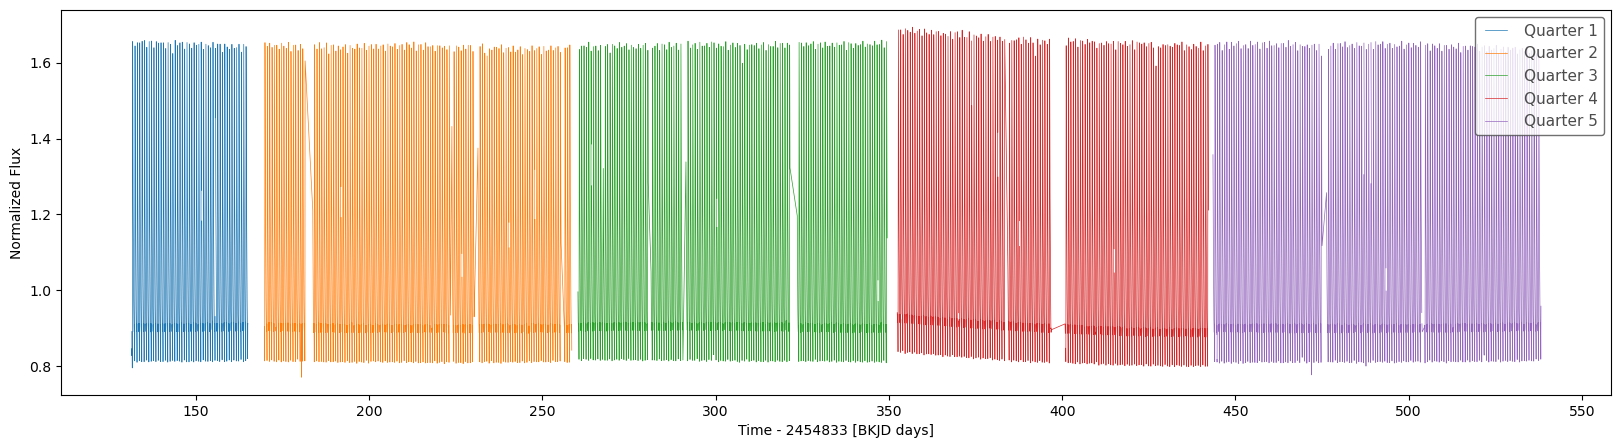

In [24]:
fig, ax = plt.subplots(figsize=(20,5))
for lc in lc_collection:
  lc.normalize().plot(ax=ax, label=f'Quarter {lc.quarter}');

In [25]:
search_result = lk.search_targetpixelfile('K2-199', exptime=1800)
search_result

#,mission,year,author,exptime,target_name,distance
,,,,s,,arcsec
0,K2 Campaign 06,2015,K2,1800,ktwo212779596,0.0
1,K2 Campaign 17,2018,K2,1800,ktwo212779596,0.0


In [26]:
tpf = search_result.download()

/Users/shanekomeiji/miniforge3/envs/AstronomicalData/lib/python3.14/site-packages/lightkurve/search.py:421: LightkurveWarning: Warning: 2 files available to download. Only the first file has been downloaded. Please use `download_all()` or specify additional criteria (e.g. quarter, campaign, or sector) to limit your search.
  warnings.warn(


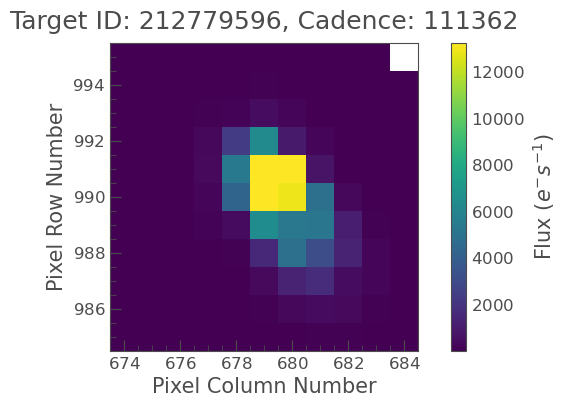

In [27]:
tpf.plot();

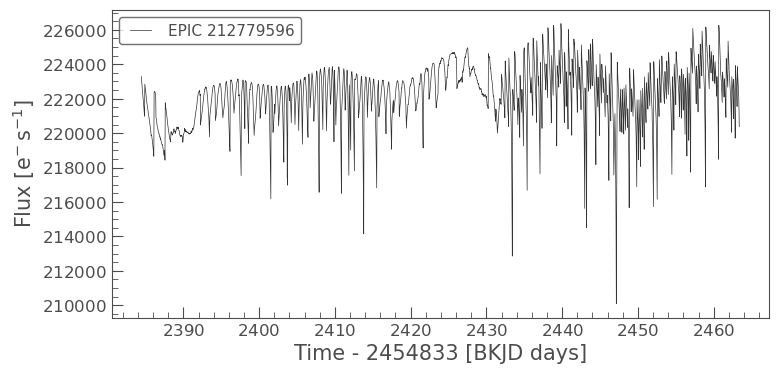

In [28]:
lc = tpf.to_lightcurve()
lc.plot();

In [29]:
tpf_collection = search_result.download_all()
tpf_collection

TargetPixelFileCollection of 2 objects:
    0: KeplerTargetPixelFile Object (ID: 212779596)
    1: KeplerTargetPixelFile Object (ID: 212779596)

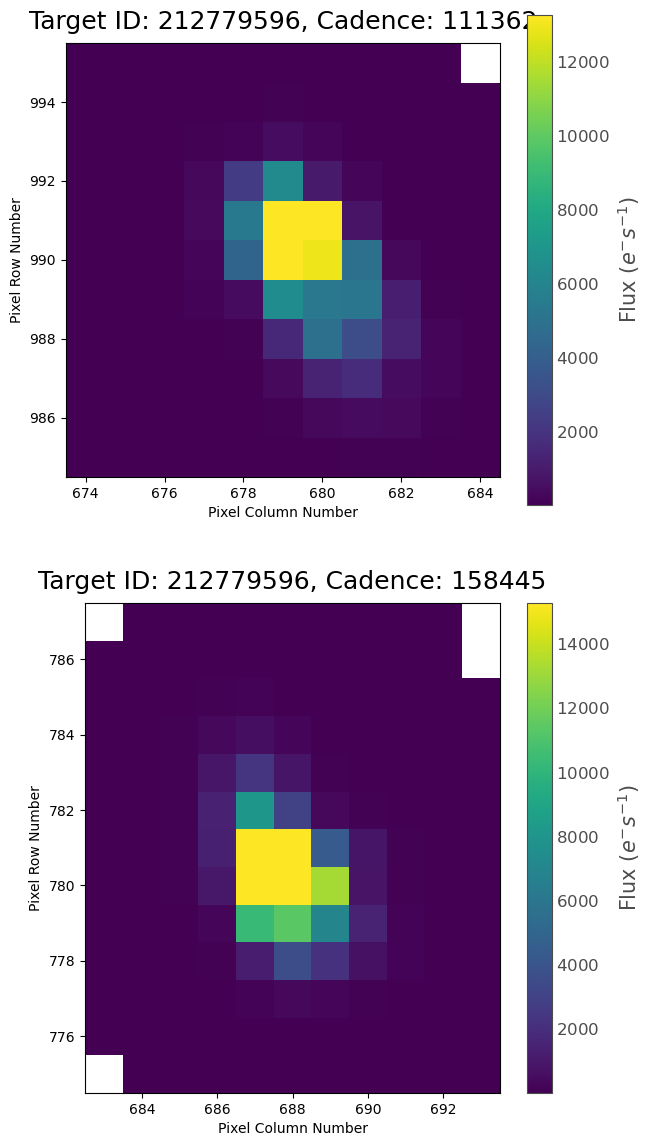

In [30]:
tpf_collection.plot();

In [31]:
search_result = lk.search_tesscut('Pi Men')
search_result

#,mission,year,author,exptime,target_name,distance
,,,,s,,arcsec
0,TESS Sector 04,2018,TESScut,1426,Pi Men,0.0
1,TESS Sector 01,2018,TESScut,1426,Pi Men,0.0
2,TESS Sector 13,2019,TESScut,1426,Pi Men,0.0
3,TESS Sector 11,2019,TESScut,1426,Pi Men,0.0
4,TESS Sector 12,2019,TESScut,1426,Pi Men,0.0
5,TESS Sector 08,2019,TESScut,1426,Pi Men,0.0
6,TESS Sector 27,2020,TESScut,475,Pi Men,0.0
7,TESS Sector 31,2020,TESScut,475,Pi Men,0.0
8,TESS Sector 28,2020,TESScut,475,Pi Men,0.0


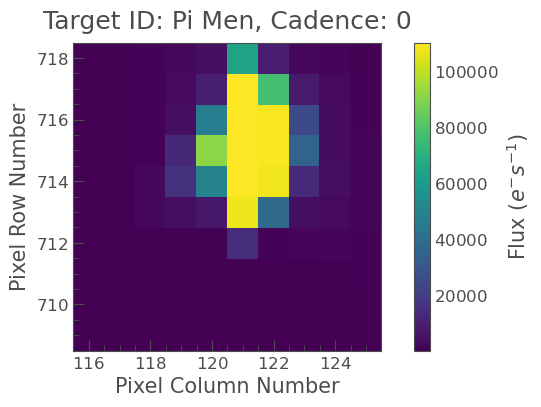

In [32]:
tpf_cutout = search_result[0].download(cutout_size=10)
tpf_cutout.plot();

In [34]:
search_result = lk.search_targetpixelfile('Trappist-1', radius=180., campaign=12, exptime=1800)
print(search_result)

SearchResult containing 3 data products.

 #     mission     year author exptime  target_name  distance
                                  s                   arcsec 
--- -------------- ---- ------ ------- ------------- --------
  0 K2 Campaign 12 2016     K2    1800 ktwo246199087      0.0
  1 K2 Campaign 12 2016     K2    1800 ktwo200164267     12.1
  2 K2 Campaign 12 2016     K2    1800 ktwo246199173     95.5


# Periodograms

In [35]:
%matplotlib inline
import lightkurve as lk

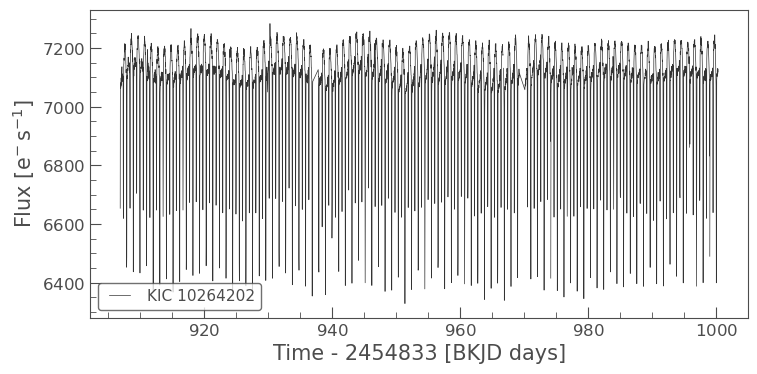

In [36]:
lc = lk.search_lightcurve('KIC 10264202', author='Kepler', quarter=10).download()
lc.plot();

In [37]:
pg = lc.normalize(unit='ppm').to_periodogram()
pg

LombScarglePeriodogram(ID: KIC 10264202)

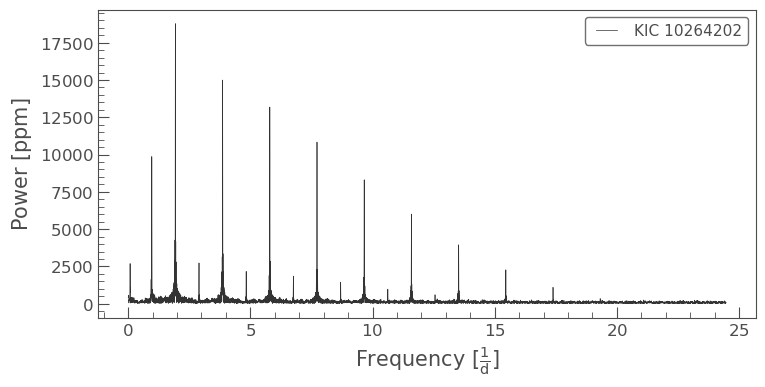

In [38]:
pg.plot();

<Axes: xlabel='Frequency [$\\mathrm{\\frac{1}{d}}$]', ylabel='Power [$\\mathrm{ppm}$]'>

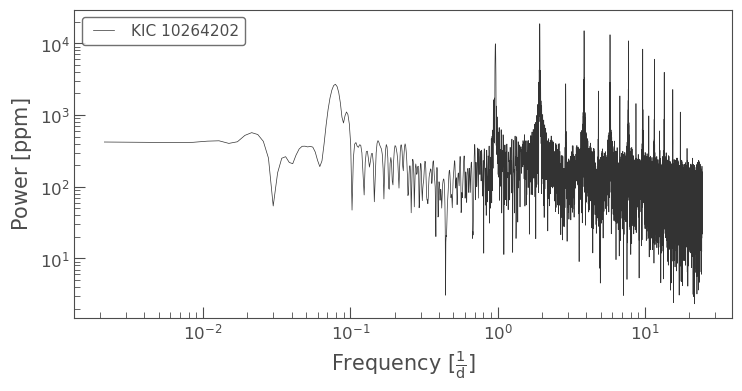

In [39]:
pg.plot(scale='log')

In [40]:
pg.show_properties()

lightkurve.Periodogram properties:
      Attribute         Description   Units
---------------------- -------------- -----
                nterms              1      
              targetid       10264202      
          default_view      frequency      
                 label   KIC 10264202      
             ls_method           fast      
frequency_at_max_power         1.9314 1 / d
             max_power     18774.4969   ppm
               nyquist        24.4695 1 / d
   period_at_max_power         0.5177     d
             frequency array (11427,) 1 / d
                period array (11427,)     d
                 power array (11427,)   ppm
                  meta <class 'dict'>      


In [41]:
period = pg.period_at_max_power
period

<Quantity 0.51774916 d>

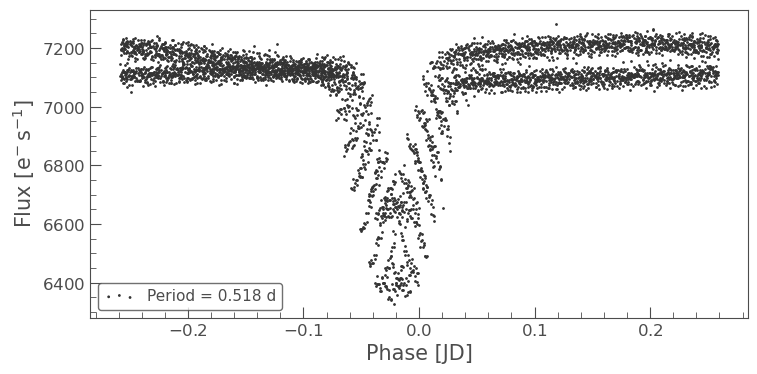

In [42]:
lc.fold(period).scatter(label=f'Period = {period.value:.3f} d');

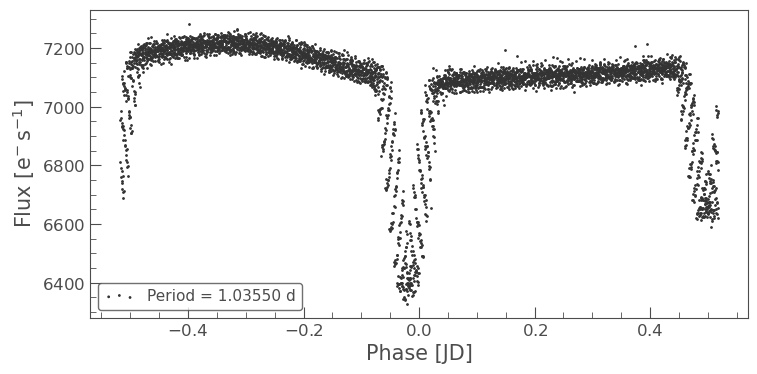

In [43]:
lc.fold(2*period).scatter(label=fr'Period = {2*period.value:.5f} d');

<Axes: xlabel='Period [$\\mathrm{d}$]', ylabel='Power [$\\mathrm{\\frac{e^{-}}{s}}$]'>

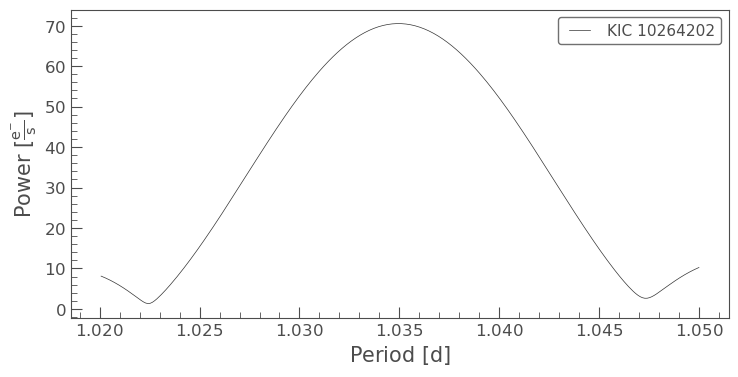

In [51]:
pg = lc.to_periodogram(minimum_period = 1.02,
                       maximum_period = 1.05,
                       oversample_factor = 100)
pg.plot(view='period')

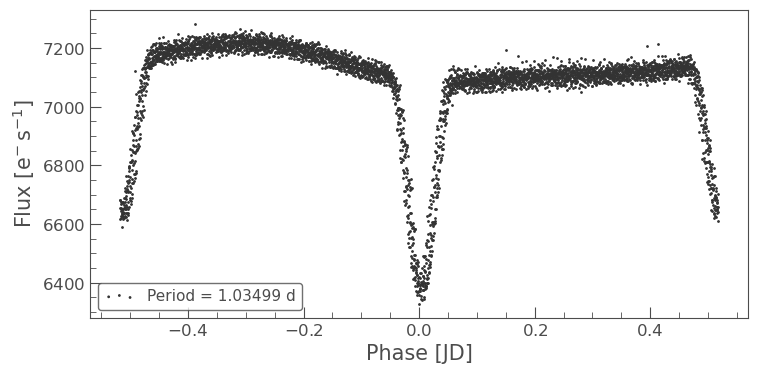

In [53]:
new_period = pg.period_at_max_power
lc.fold(new_period).scatter(label=rf'Period = {new_period.value:.5f} d');

# Intro to astroseismology

In [55]:
search_result = lk.search_lightcurve('KIC 10963065',
                                     cadence='short',
                                     author='Kepler',
                                     quarter=(2,5,6,7))
lc = search_result.download_all().stitch()

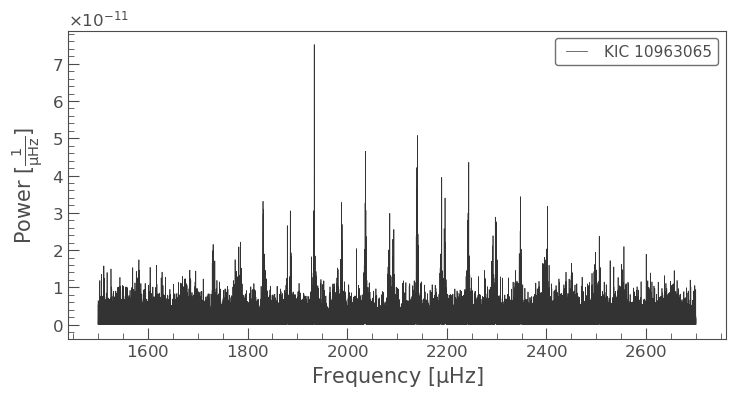

In [56]:
pg = lc.to_periodogram(normalization='psd',
                       minimum_frequency=1500,
                       maximum_frequency=2700)
ax = pg.plot();

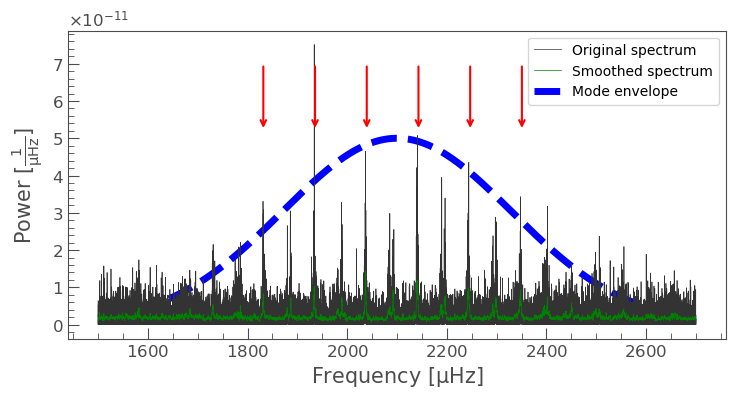

In [57]:
# Plot a smoothed version of the power spectrum on top in green
ax = pg.plot(label='Original spectrum')
pg.smooth(filter_width=1).plot(ax=ax,
                               color='green',
                               label='Smoothed spectrum')

# Highlight the "mode envelope" using a Gaussian curve
f = pg.frequency.value
ax.plot(f, 5e-11*np.exp(-(f-2100)**2/(2*230**2)),
        lw=5, ls='--', zorder=0,
        color='blue', label='Mode envelope');

# Annotate the modes using red arrows
for i in range(6):
  ax.annotate('',
              xy=(1831.66+i*103.8, 5.2e-11),
              xytext=(1831.66+i*103.8, 7e-11),
              arrowprops=dict(arrowstyle='->',
              color='red',
              linewidth=1.5))
ax.legend();

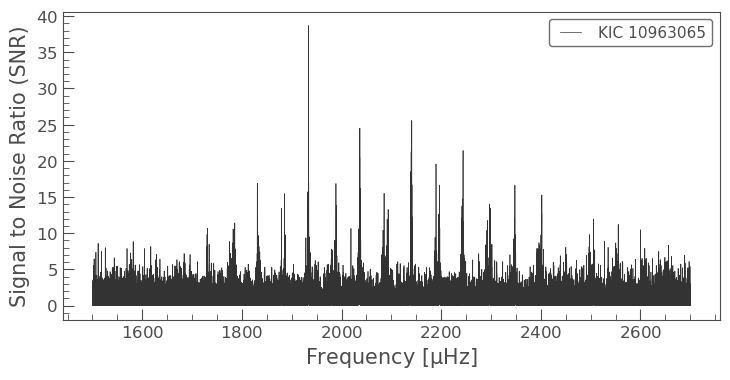

In [58]:
snr = pg.flatten()
ax = snr.plot();

In [59]:
seismology = snr.to_seismology()

In [60]:
seismology.estimate_numax()

numax: 2145.00 uHz (method: ACF2D)

In [61]:
seismology.numax.value

np.float64(2145.0)

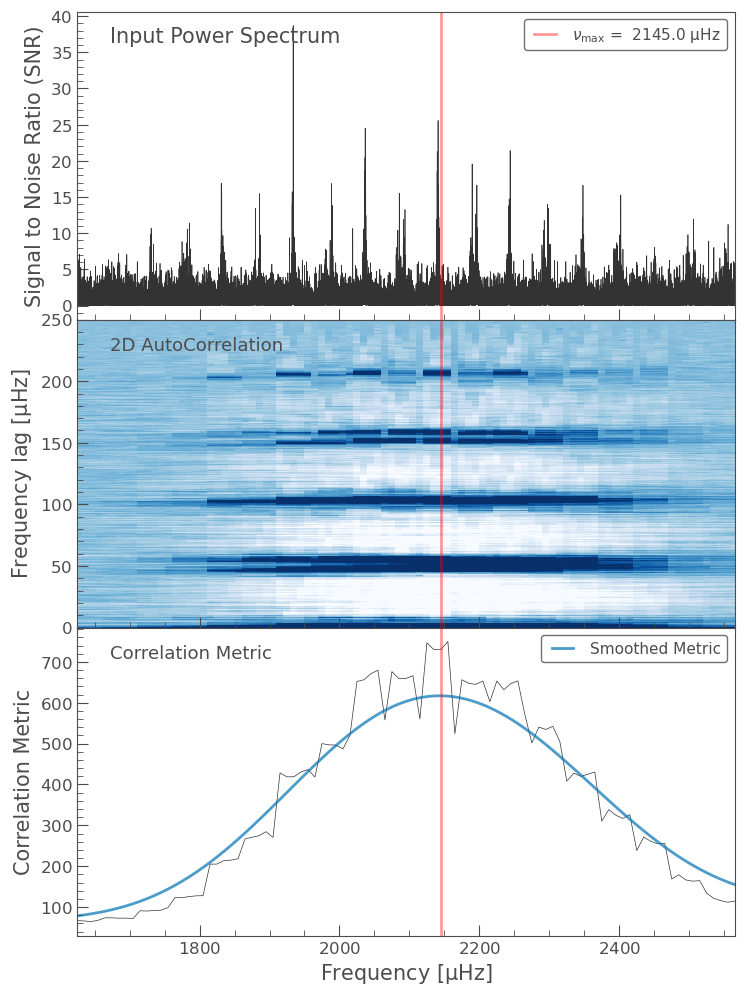

In [62]:
seismology.diagnose_numax();

In [63]:
seismology.estimate_deltanu()

deltanu: 103.11 uHz (method: ACF2D)

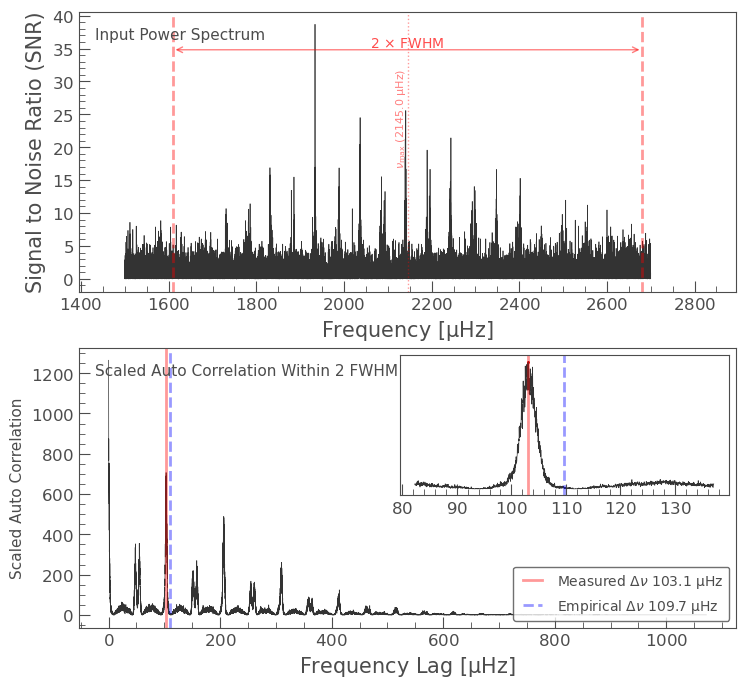

In [64]:
seismology.diagnose_deltanu();

In [65]:
seismology.estimate_mass()

/Users/shanekomeiji/miniforge3/envs/AstronomicalData/lib/python3.14/site-packages/uncertainties/core.py:1024: UserWarning: Using UFloat objects with std_dev==0 may give unexpected results.
  warn("Using UFloat objects with std_dev==0 may give unexpected results.")


mass: 1.08 solMass (method: Uncorrected Scaling Relations)

In [66]:
seismology.estimate_radius()

radius: 1.23 solRad (method: Uncorrected Scaling Relations)

In [67]:
seismology.estimate_logg()

logg: 4.29 dex (method: Uncorrected Scaling Relations)

In [68]:
seismology

Seismology(ID: KIC 10963065) - computed values:
 * numax: 2145.00 uHz (method: ACF2D)
 * deltanu: 103.11 uHz (method: ACF2D)
 * mass: 1.08 solMass (method: Uncorrected Scaling Relations)
 * radius: 1.23 solRad (method: Uncorrected Scaling Relations)
 * logg: 4.29 dex (method: Uncorrected Scaling Relations)